🧹 GLOBAL INFLATION ANALYSIS - DATA CLEANING
📥 Loaded 7418 observations from 'inflation_raw.csv'
   Columns: ['Country', 'economy', 'Indicator Name', 'Indicator Code', 'Year', 'Inflation_Rate', 'GDP_Growth', 'GDP_Per_Capita', 'Unemployment', 'Region', 'IncomeLevel', 'Decade', 'Inflation_Category', 'High_Inflation']

🔍 INITIAL INSPECTION

📊 Data Types:
Country                object
economy                object
Indicator Name         object
Indicator Code         object
Year                    int64
Inflation_Rate        float64
GDP_Growth            float64
GDP_Per_Capita        float64
Unemployment          float64
Region                 object
IncomeLevel            object
Decade                  int64
Inflation_Category     object
High_Inflation           bool
dtype: object

📊 Missing Values:
                Missing_Count  Missing_Percent
GDP_Growth                 41         0.552710
GDP_Per_Capita             33         0.444864
Unemployment              506         6.821246

📊 Sam

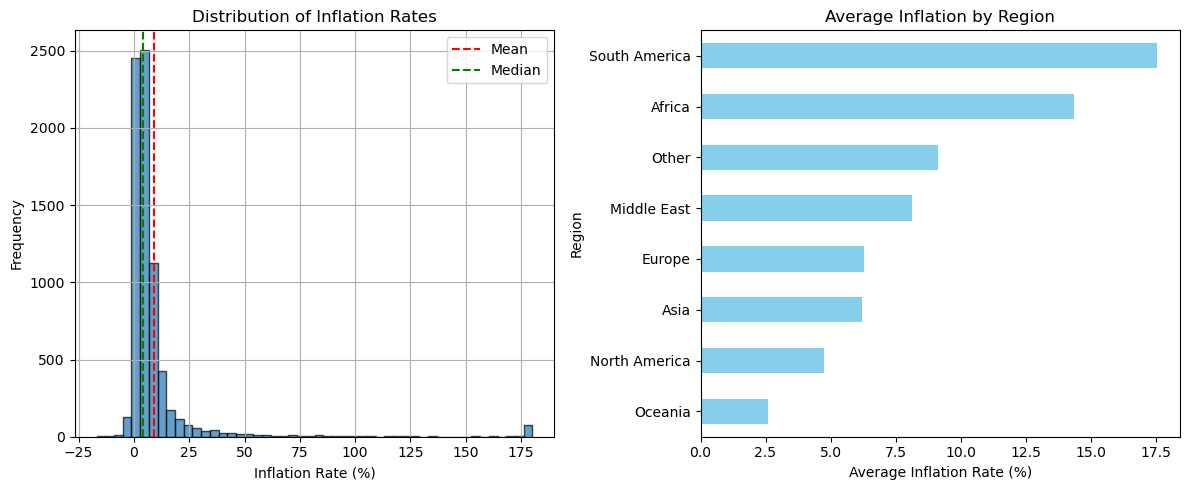


✅ Data cleaning complete!


In [3]:
# ============================================
# 02_data_cleaning.ipynb - SIMPLIFIED
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("🧹 GLOBAL INFLATION ANALYSIS - DATA CLEANING")
print("=" * 60)

# ============================================
# 1. Load the Data (from same folder)
# ============================================

df = pd.read_csv('inflation_clean.csv') 
print(f"📥 Loaded {len(df)} observations from 'inflation_raw.csv'")
print(f"   Columns: {list(df.columns)}")

# ============================================
# 2. Initial Inspection
# ============================================

print("\n" + "=" * 60)
print("🔍 INITIAL INSPECTION")
print("=" * 60)

print("\n📊 Data Types:")
print(df.dtypes)

print("\n📊 Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_pct
})
print(missing_df[missing_df['Missing_Count'] > 0])

print("\n📊 Sample Data:")
print(df.head())

# ============================================
# 3. Handle Missing Values
# ============================================

print("\n" + "=" * 60)
print("🛠️ HANDLING MISSING VALUES")
print("=" * 60)

# Find the inflation column
inflation_col = 'Inflation_Rate'
if inflation_col not in df.columns:
    for col in df.columns:
        if 'inflation' in col.lower():
            inflation_col = col
            break

print(f"Using inflation column: '{inflation_col}'")

# Check countries with most missing data
missing_by_country = df.groupby('Country')[inflation_col].apply(lambda x: x.isnull().sum())
missing_by_country = missing_by_country.sort_values(ascending=False)
print("\nCountries with most missing inflation data:")
print(missing_by_country.head(10))

# Filter out countries with > 50% missing data
threshold = 0.5
country_missing_pct = df.groupby('Country')[inflation_col].apply(
    lambda x: x.isnull().sum() / len(x)
)
valid_countries = country_missing_pct[country_missing_pct <= threshold].index
df_filtered = df[df['Country'].isin(valid_countries)].copy()

print(f"\n✅ Removed countries with >50% missing data")
print(f"   Countries kept: {len(valid_countries)}")
print(f"   Observations kept: {len(df_filtered)}")

# ============================================
# 4. Handle Outliers
# ============================================

print("\n" + "=" * 60)
print("📊 HANDLING OUTLIERS")
print("=" * 60)

# Check inflation distribution
print("\n📊 Inflation Distribution Statistics:")
print(df_filtered[inflation_col].describe())

# Identify extreme outliers
extreme_outliers = df_filtered[df_filtered[inflation_col] > 100]
print(f"\n⚠️ Observations with inflation > 100%: {len(extreme_outliers)}")
if len(extreme_outliers) > 0:
    print(extreme_outliers[['Country', 'Year', inflation_col]].head(10))

# Cap outliers at 99th percentile
p99 = df_filtered[inflation_col].quantile(0.99)
df_cleaned = df_filtered.copy()
df_cleaned['Inflation_Rate_Capped'] = df_cleaned[inflation_col].clip(upper=p99)

print(f"\n✅ Capped inflation at {p99:.1f}% (99th percentile)")

# ============================================
# 5. Create Derived Features
# ============================================

print("\n" + "=" * 60)
print("🔧 CREATING DERIVED FEATURES")
print("=" * 60)

# Inflation category
def inflation_category(rate):
    if pd.isna(rate):
        return 'Unknown'
    elif rate < 2:
        return 'Low (<2%)'
    elif rate < 5:
        return 'Moderate (2-5%)'
    elif rate < 10:
        return 'High (5-10%)'
    else:
        return 'Very High (>10%)'

df_cleaned['Inflation_Category'] = df_cleaned['Inflation_Rate_Capped'].apply(inflation_category)

# Decade column
if 'Decade' not in df_cleaned.columns:
    df_cleaned['Decade'] = (df_cleaned['Year'] // 10) * 10

print("✅ Created features: Inflation_Category, Decade")

# ============================================
# 6. Validate Cleaned Data
# ============================================

print("\n" + "=" * 60)
print("✅ VALIDATION")
print("=" * 60)

print(f"\n📊 Cleaned Dataset:")
print(f"   Observations: {len(df_cleaned)}")
print(f"   Countries: {df_cleaned['Country'].nunique()}")
print(f"   Years: {df_cleaned['Year'].min()} - {df_cleaned['Year'].max()}")
print(f"   Inflation Range: {df_cleaned['Inflation_Rate_Capped'].min():.1f}% to {df_cleaned['Inflation_Rate_Capped'].max():.1f}%")

# ============================================
# 7. Save Everything in Current Folder
# ============================================

print("\n" + "=" * 60)
print("💾 SAVING CLEANED DATASET")
print("=" * 60)

# Select final columns that exist
final_columns = ['economy', 'Country', 'Region', 'IncomeLevel', 'Year', 'Decade',
                 'Inflation_Rate', 'Inflation_Rate_Capped', 'Inflation_Category',
                 'GDP_Growth', 'GDP_Per_Capita']
final_columns = [col for col in final_columns if col in df_cleaned.columns]

df_final = df_cleaned[final_columns].copy()

# Save to same folder
df_final.to_csv('inflation_cleaned.csv', index=False)
print("✅ Saved 'inflation_cleaned.csv' in current folder")

# Country summary
country_summary = df_final.groupby('Country').agg({
    'Inflation_Rate_Capped': ['mean', 'std', 'min', 'max'],
    'Year': ['min', 'max']
}).round(2)

country_summary.columns = ['Avg_Inflation', 'Std_Inflation', 'Min_Inflation', 'Max_Inflation', 'First_Year', 'Last_Year']
country_summary = country_summary.reset_index()
country_summary.to_csv('country_summary.csv', index=False)
print("✅ Saved 'country_summary.csv' in current folder")

# ============================================
# 8. Quick Visualizations
# ============================================

print("\n" + "=" * 60)
print("📊 QUICK VISUALIZATIONS")
print("=" * 60)

# Plot inflation distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_final['Inflation_Rate_Capped'].hist(bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Inflation Rates')
plt.axvline(df_final['Inflation_Rate_Capped'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df_final['Inflation_Rate_Capped'].median(), color='green', linestyle='--', label='Median')
plt.legend()

plt.subplot(1, 2, 2)
avg_inflation_by_region = df_final.groupby('Region')['Inflation_Rate_Capped'].mean().sort_values()
avg_inflation_by_region.plot(kind='barh', color='skyblue')
plt.xlabel('Average Inflation Rate (%)')
plt.title('Average Inflation by Region')
plt.tight_layout()

# Save in current folder
plt.savefig('inflation_distribution.png', dpi=150, bbox_inches='tight')
print("✅ Saved 'inflation_distribution.png' in current folder")
plt.show()

print("\n✅ Data cleaning complete!")